# Vietnamese Malicious Comment Detection with PhoBERT + BiLSTM
Binary classification: 0 = Clean, 1 = Malicious

## 1. Install & Import Libraries

In [1]:
!pip install transformers underthesea -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.7 MB/s eta 0:00:00


In [2]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from underthesea import word_tokenize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix

from transformers import (
    AutoModel,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
    logging,
 )

warnings.filterwarnings("ignore")
logging.set_verbosity_error()

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"Memory: {props.total_memory / 1024**3:.1f} GB")
else:
    print("GPU not available, using CPU")

Using device: cuda
GPU: Tesla T4
Memory: 14.6 GB


In [4]:
def seed_everything(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)

seed_everything(42)

In [5]:
EPOCHS = 6
N_SPLITS = 5
BATCH_SIZE = 16
MAX_LEN = 128
LEARNING_RATE = 2e-5
MODEL_NAME = "vinai/phobert-base"
NUM_WORKERS = 0  # Kaggle does not support num_workers > 0 reliably

# Kaggle paths
KAGGLE_INPUT = "/kaggle/input"
KAGGLE_OUTPUT = "/kaggle/working"

# Define data paths for Kaggle dataset structure
KAGGLE_DATASET_PATH = "/kaggle/input/datasets/viethoang0805/vietnamesebullydataset"

# Auto-detect: Kaggle or local
if os.path.exists(KAGGLE_DATASET_PATH):
    DATA_CSV = os.path.join(KAGGLE_DATASET_PATH, "data.csv")
    STOPWORDS_PATH = os.path.join(KAGGLE_DATASET_PATH, "vietnamese_stopwords.txt")
    SAVE_DIR = KAGGLE_OUTPUT
elif os.path.exists(KAGGLE_INPUT):
    DATA_DIR = None
    for d in os.listdir(KAGGLE_INPUT):
        candidate = os.path.join(KAGGLE_INPUT, d)
        if os.path.isfile(os.path.join(candidate, "data.csv")) or \
           os.path.isfile(os.path.join(candidate, "data", "data.csv")):
            DATA_DIR = candidate
            break
    if DATA_DIR is None:
        DATA_DIR = os.path.join(KAGGLE_INPUT, os.listdir(KAGGLE_INPUT)[0]) if os.listdir(KAGGLE_INPUT) else "."
    if os.path.isfile(os.path.join(DATA_DIR, "data.csv")):
        DATA_CSV = os.path.join(DATA_DIR, "data.csv")
        STOPWORDS_PATH = os.path.join(DATA_DIR, "vietnamese_stopwords.txt")
    else:
        DATA_CSV = os.path.join(DATA_DIR, "data", "data.csv")
        STOPWORDS_PATH = os.path.join(DATA_DIR, "data", "vietnamese_stopwords.txt")
    SAVE_DIR = KAGGLE_OUTPUT
else:
    DATA_CSV = "data/data.csv"
    STOPWORDS_PATH = "data/vietnamese_stopwords.txt"
    SAVE_DIR = "."

print(f"Data CSV      : {DATA_CSV}")
print(f"Stopwords     : {STOPWORDS_PATH}")
print(f"Output dir    : {SAVE_DIR}")

Data CSV      : /kaggle/input/datasets/viethoang0805/vietnamesebullydataset/data.csv
Stopwords     : /kaggle/input/datasets/viethoang0805/vietnamesebullydataset/vietnamese_stopwords.txt
Output dir    : /kaggle/working


## 2. Load Dataset & Stopwords

In [6]:
data = pd.read_csv(DATA_CSV)
data = data.iloc[:, 1:]
print(data.info())
print(f"\nLabel distribution:\n{data['label'].value_counts()}")
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11056 entries, 0 to 11055
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  11056 non-null  object
 1   label    11056 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 172.9+ KB
None

Label distribution:
label
0    5696
1    5360
Name: count, dtype: int64


,content,label
0,Dừa lắm :)),0
1,Bấp bênh vl thế,1
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,1
3,Thấy chán ad page này kiến thức thì nông cản c...,1
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,0
5,đcm 😒 sau có con cho hút cỏ chữa bệnh chứ đéo ...,1
6,Má nứng quá aiu ơi,1
7,Chụp cái ảnh thôi làm đéo gì đâu mà phiền,1
8,Tăng theo giờ 😭😭😭,0
9,Cực kì thuyết phục :c,0


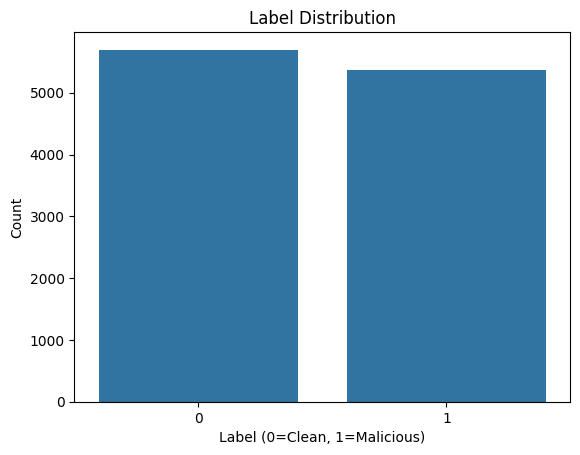

In [7]:
sns.countplot(x="label", data=data)
plt.title("Label Distribution")
plt.xlabel("Label (0=Clean, 1=Malicious)")
plt.ylabel("Count")
plt.show()

In [8]:
with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
    stopwords = set(line.strip() for line in f.readlines())

print(f"Loaded {len(stopwords)} stopwords")
print(f"Sample: {list(stopwords)[:10]}")

Loaded 1942 stopwords
Sample: ['vụt', 'nói xa', 'sang sáng', 'mỗi ngày', 'tớ', 'thôi', 'nghe ra', 'thi thoảng', 'quả thế', 'lúc đó']


## 3. Text Preprocessing

In [9]:
def preprocess_text(text, remove_stopwords=True):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s\u00C0-\u024F\u1E00-\u1EFF]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = word_tokenize(text, format="text")
    if remove_stopwords:
        words = [w for w in text.split() if w not in stopwords]
        text = " ".join(words)
    return text

sample = data.iloc[3]["content"]
print(f"Original : {sample}")
print(f"Processed: {preprocess_text(sample)}")

Original : Thấy chán ad page này kiến thức thì nông cản cái gì cũng auto sủa, cái nhìn thì tiêu cực, nói chung là dốt còn nát
Processed: chán ad_page kiến_thức nông_cản auto_sủa tiêu_cực nói_chung dốt nát


In [10]:
data["content_clean"] = data["content"].apply(preprocess_text)
data[["content", "content_clean", "label"]].head(10)

,content,content_clean,label
0,Dừa lắm :)),dừa lắm,0
1,Bấp bênh vl thế,bấp_bênh vl,1
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,ko tồn_tại đc bao_lâu cố_gắng vét,1
3,Thấy chán ad page này kiến thức thì nông cản c...,chán ad_page kiến_thức nông_cản auto_sủa tiêu_...,1
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,giang_giang đỗ_thị ngọc_hà trend kìa kìa,0
5,đcm 😒 sau có con cho hút cỏ chữa bệnh chứ đéo ...,đcm hút cỏ chữa bệnh đéo đi bệnh_viện,1
6,Má nứng quá aiu ơi,má nứng aiu,1
7,Chụp cái ảnh thôi làm đéo gì đâu mà phiền,chụp ảnh đéo phiền,1
8,Tăng theo giờ 😭😭😭,,0
9,Cực kì thuyết phục :c,cực_kì thuyết_phục c,0


## 4. Train/Test Split

In [11]:
train_df = data.iloc[:int(len(data) * 0.8)].reset_index(drop=True)
test_df = data.iloc[int(len(data) * 0.8):].reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Test size : {len(test_df)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts()}")

Train size: 8844
Test size : 2212

Train label distribution:
label
0    4552
1    4292
Name: count, dtype: int64

Test label distribution:
label
0    1144
1    1068
Name: count, dtype: int64


In [12]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=86)
for fold, (_, val_) in enumerate(skf.split(X=train_df, y=train_df.label)):
    train_df.loc[val_, "kfold"] = fold

train_df["kfold"] = train_df["kfold"].astype(int)
train_df.head()

,content,label,content_clean,kfold
0,Dừa lắm :)),0,dừa lắm,2
1,Bấp bênh vl thế,1,bấp_bênh vl,4
2,Chắc cũng biết ko tồn tại đc bao lâu nữa nên c...,1,ko tồn_tại đc bao_lâu cố_gắng vét,3
3,Thấy chán ad page này kiến thức thì nông cản c...,1,chán ad_page kiến_thức nông_cản auto_sủa tiêu_...,0
4,Giang Giang Đỗ Thị Ngọc Hà trend mới kìa kìa,0,giang_giang đỗ_thị ngọc_hà trend kìa kìa,1


## 5. Tokenizer & Dataset

In [13]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
print(f"Vocab size: {tokenizer.vocab_size}")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 64000


Max token length : 170
Mean token length: 10.4
95th percentile  : 26


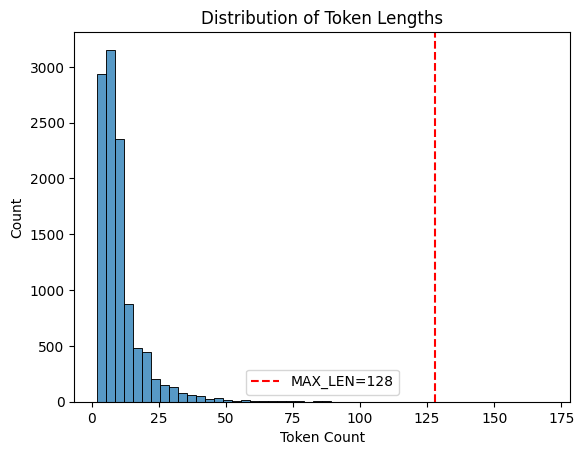

In [14]:
all_texts = data["content_clean"].tolist()
encoded_texts = [tokenizer.encode(text, add_special_tokens=True) for text in all_texts]
token_lens = [len(t) for t in encoded_texts]

print(f"Max token length : {max(token_lens)}")
print(f"Mean token length: {np.mean(token_lens):.1f}")
print(f"95th percentile  : {np.percentile(token_lens, 95):.0f}")

sns.histplot(token_lens, bins=50)
plt.xlabel("Token Count")
plt.title("Distribution of Token Lengths")
plt.axvline(x=MAX_LEN, color="r", linestyle="--", label=f"MAX_LEN={MAX_LEN}")
plt.legend()
plt.show()

In [15]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.max_len = max_len
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        text = row["content_clean"]
        label = row["label"]

        encoding = self.tokenizer(
            text,
            truncation=True,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            return_attention_mask=True,
            return_token_type_ids=False,
            return_tensors="pt",
        )

        return {
            "text": text,
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "targets": torch.tensor(label, dtype=torch.long),
        }

In [16]:
def prepare_loaders(df, fold):
    df_train = df[df.kfold != fold].reset_index(drop=True)
    df_valid = df[df.kfold == fold].reset_index(drop=True)

    train_dataset = SentimentDataset(df_train, tokenizer, max_len=MAX_LEN)
    valid_dataset = SentimentDataset(df_valid, tokenizer, max_len=MAX_LEN)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    return train_loader, valid_loader

## 6. PhoBERT + BiLSTM Model

In [17]:
class PhoBertBiLSTMClassifier(nn.Module):
    def __init__(self, n_classes=2, hidden_size=256, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.bilstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        sequence_output = outputs.last_hidden_state
        _, (h_n, _) = self.bilstm(sequence_output)
        # h_n: (num_layers * num_directions, batch, hidden_size)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        pooled = torch.cat([h_forward, h_backward], dim=1)
        x = self.dropout(pooled)
        x = self.fc(x)
        return x

## 7. Training & Evaluation Functions

In [18]:
def train_epoch(model, criterion, optimizer, scheduler, train_loader):
    model.train()
    losses = []
    correct = 0
    total = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["targets"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, targets)

        _, pred = torch.max(outputs, dim=1)
        correct += torch.sum(pred == targets).item()
        total += targets.size(0)
        losses.append(loss.item())

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

    acc = correct / total
    avg_loss = np.mean(losses)
    return acc, avg_loss


def eval_epoch(model, criterion, data_loader):
    model.eval()
    losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["targets"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, targets)

            _, pred = torch.max(outputs, dim=1)
            correct += torch.sum(pred == targets).item()
            total += targets.size(0)
            losses.append(loss.item())

    acc = correct / total
    avg_loss = np.mean(losses)
    return acc, avg_loss

## 8. Train (with class weights + early stopping)

In [19]:
fold_results = []

for fold in range(N_SPLITS):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{N_SPLITS}")
    print(f"{'='*60}")

    train_loader, valid_loader = prepare_loaders(train_df, fold=fold)

    model = PhoBertBiLSTMClassifier(n_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps,
    )

    best_val_acc = 0
    for epoch in range(EPOCHS):
        train_acc, train_loss = train_epoch(
            model, criterion, optimizer, scheduler, train_loader
        )
        val_acc, val_loss = eval_epoch(model, criterion, valid_loader)

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Acc: {train_acc:.4f} Loss: {train_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} Loss: {val_loss:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            os.makedirs(SAVE_DIR, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"phobert_bilstm_fold{fold+1}.pth"))

    fold_results.append(best_val_acc)
    print(f"Best Val Accuracy for Fold {fold+1}: {best_val_acc:.4f}")

print(f"\n{'='*60}")
print(f"Average Val Accuracy: {np.mean(fold_results):.4f} (+/- {np.std(fold_results):.4f})")


FOLD 1/5


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Epoch 1/6 | Train Acc: 0.7560 Loss: 0.4936 | Val Acc: 0.8508 Loss: 0.3418
Epoch 2/6 | Train Acc: 0.8743 Loss: 0.3091 | Val Acc: 0.8779 Loss: 0.3057
Epoch 3/6 | Train Acc: 0.9128 Loss: 0.2381 | Val Acc: 0.8705 Loss: 0.4107
Epoch 4/6 | Train Acc: 0.9388 Loss: 0.1812 | Val Acc: 0.8841 Loss: 0.3821
Epoch 5/6 | Train Acc: 0.9555 Loss: 0.1561 | Val Acc: 0.8836 Loss: 0.4388
Epoch 6/6 | Train Acc: 0.9634 Loss: 0.1322 | Val Acc: 0.8824 Loss: 0.4522
Best Val Accuracy for Fold 1: 0.8841

FOLD 2/5


...

Epoch 1/6 | Train Acc: 0.7593 Loss: 0.4888 | Val Acc: 0.8581 Loss: 0.3427
Epoch 2/6 | Train Acc: 0.8683 Loss: 0.3217 | Val Acc: 0.8836 Loss: 0.3119
Epoch 3/6 | Train Acc: 0.9139 Loss: 0.2354 | Val Acc: 0.8841 Loss: 0.3528
Epoch 4/6 | Train Acc: 0.9384 Loss: 0.1887 | Val Acc: 0.8892 Loss: 0.3633
Epoch 5/6 | Train Acc: 0.9548 Loss: 0.1486 | Val Acc: 0.8807 Loss: 0.4604
Epoch 6/6 | Train Acc: 0.9642 Loss: 0.1223 | Val Acc: 0.8824 Loss: 0.4750
Best Val Accuracy for Fold 3: 0.8892

FOLD 4/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/6 | Train Acc: 0.7630 Loss: 0.4813 | Val Acc: 0.8146 Loss: 0.4446
Epoch 2/6 | Train Acc: 0.8765 Loss: 0.3088 | Val Acc: 0.8536 Loss: 0.3725
Epoch 3/6 | Train Acc: 0.9162 Loss: 0.2243 | Val Acc: 0.8705 Loss: 0.3427
Epoch 4/6 | Train Acc: 0.9430 Loss: 0.1751 | Val Acc: 0.8745 Loss: 0.4338
Epoch 5/6 | Train Acc: 0.9582 Loss: 0.1443 | Val Acc: 0.8677 Loss: 0.5718
Epoch 6/6 | Train Acc: 0.9644 Loss: 0.1226 | Val Acc: 0.8711 Loss: 0.5506
Best Val Accuracy for Fold 4: 0.8745

FOLD 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Epoch 1/6 | Train Acc: 0.7431 Loss: 0.5103 | Val Acc: 0.8479 Loss: 0.3416
Epoch 2/6 | Train Acc: 0.8693 Loss: 0.3194 | Val Acc: 0.8552 Loss: 0.3432
Epoch 3/6 | Train Acc: 0.9141 Loss: 0.2377 | Val Acc: 0.8824 Loss: 0.3357
Epoch 4/6 | Train Acc: 0.9357 Loss: 0.1953 | Val Acc: 0.8925 Loss: 0.3718
Epoch 5/6 | Train Acc: 0.9512 Loss: 0.1591 | Val Acc: 0.8784 Loss: 0.5088
Epoch 6/6 | Train Acc: 0.9617 Loss: 0.1378 | Val Acc: 0.8903 Loss: 0.4785
Best Val Accuracy for Fold 5: 0.8925

Average Val Accuracy: 0.8855 (+/- 0.0061)


## 9. Test Evaluation (Ensemble)

In [20]:
def test_ensemble(test_df, tokenizer, n_folds=N_SPLITS):
    models = []
    for fold in range(n_folds):
        try:
            model_path = os.path.join(SAVE_DIR, f"phobert_bilstm_fold{fold+1}.pth")
            if os.path.exists(model_path):
                m = PhoBertBiLSTMClassifier(n_classes=2).to(device)
                m.load_state_dict(torch.load(model_path, map_location=device))
                m.eval()
                models.append(m)
        except Exception as e:
            print(f"Warning: Could not load fold {fold+1}: {e}")

    if not models:
        print("Error: No models loaded!")
        return None, None, None

    test_dataset = SentimentDataset(test_df, tokenizer, max_len=MAX_LEN)
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    all_preds = []
    all_targets = []
    all_texts = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["targets"]

            fold_outputs = []
            for m in models:
                outputs = m(input_ids=input_ids, attention_mask=attention_mask)
                fold_outputs.append(outputs)

            avg_outputs = torch.stack(fold_outputs).mean(0)
            _, preds = torch.max(avg_outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())
            all_texts.extend(batch["text"])

    return np.array(all_targets), np.array(all_preds), all_texts

## 10. Confusion Matrix


Evaluating on test set...
Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

                precision    recall  f1-score   support

Clean (0)          0.8915    0.8977    0.8946      1144
Malicious (1)      0.8896    0.8830    0.8863      1068

accuracy                               0.8906      2212
macro avg          0.8906    0.8903    0.8904      2212
weighted avg       0.8906    0.8906    0.8906      2212


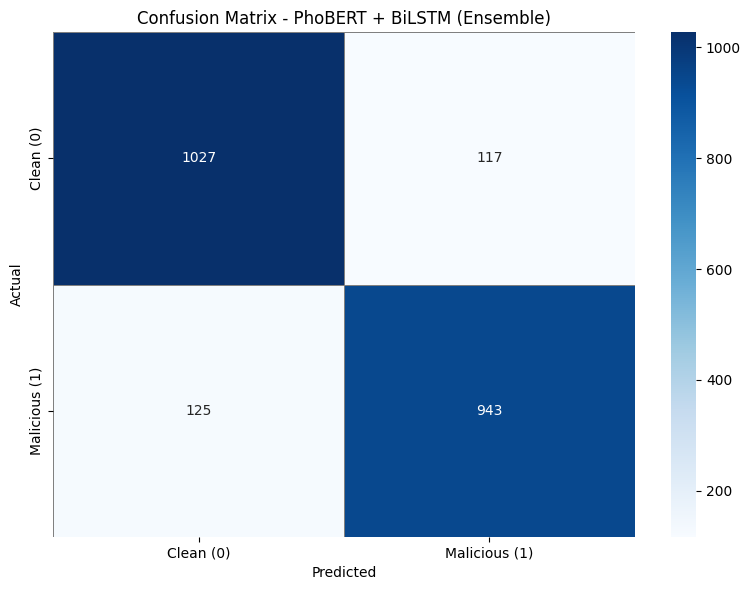

In [ ]:
print("Evaluating on test set...")
real_values, predicts, texts = test_ensemble(test_df, tokenizer)

if real_values is not None:
    print("\n" + "="*60)
    print(classification_report(real_values, predicts, target_names=["Clean (0)", "Malicious (1)"]))
    print("="*60)

    cm = confusion_matrix(real_values, predicts)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Clean (0)", "Malicious (1)"],
        yticklabels=["Clean (0)", "Malicious (1)"],
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - PhoBERT + BiLSTM (Ensemble)")
    plt.show()
else:
    print("Could not evaluate - models not available yet")

## 11. Error Analysis

In [22]:
if real_values is not None:
    wrong_indices = np.where(predicts != real_values)[0]
    print(f"Total wrong predictions: {len(wrong_indices)} / {len(real_values)}")
    print(f"Error rate: {len(wrong_indices)/len(real_values)*100:.2f}%\n")

    for i in wrong_indices[:15]:
        print("-" * 60)
        print(f"Text: {test_df.iloc[i]['content']}")
        print(f"Predicted: {predicts[i]} | Actual: {real_values[i]}")
else:
    print("Cannot analyze errors - run test evaluation first")

Total wrong predictions: 257 / 2212
Error rate: 11.62%

------------------------------------------------------------
Text: Gia cát bị đồng bóng à
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: đungs v
Predicted: 1 | Actual: 0
------------------------------------------------------------
Text: Lũ pede xạo xự. Mới hơm qua chúng tâng nhau lên mây. Nay chúng siủa cắn nhau như chó tháng 7. Hahaaaaaaa
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: tr ơi nhìn thầy giống con póng quá à.
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: nó ko cộng điểm, mà nó cho thí sinh rớt bớt thôi, có bà chị gặp vụ này r :)))) thi điểm cao vẫn rớt nhé
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: Huỳnh Tuấn phản động đó bạn
Predicted: 0 | Actual: 1
------------------------------------------------------------
Text: 90tr dân 

## 12. Inference

In [23]:
def predict(text, tokenizer, model, device):
    """Predict sentiment for a given text"""
    label_map = {0: "Clean", 1: "Malicious"}
    processed = preprocess_text(text)

    encoding = tokenizer(
        processed,
        max_length=MAX_LEN,
        truncation=True,
        add_special_tokens=True,
        padding="max_length",
        return_attention_mask=True,
        return_token_type_ids=False,
        return_tensors="pt",
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_ids, attention_mask)
        probs = torch.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    label = label_map[pred.item()]
    conf = confidence.item()

    print(f"Text       : {text}")
    print(f"Prediction : {label} (confidence: {conf:.4f})")
    return label, conf


if len(fold_results) > 0:
    best_fold = np.argmax(fold_results) + 1
    model_path = os.path.join(SAVE_DIR, f"phobert_bilstm_fold{best_fold}.pth")

    if os.path.exists(model_path):
        print(f"Loading best model from fold {best_fold}")
        best_model = PhoBertBiLSTMClassifier(n_classes=2).to(device)
        best_model.load_state_dict(torch.load(model_path, map_location=device))
        best_model.eval()

        print("\n" + "=" * 60)
        print("Testing on sample sentences:")
        print("=" * 60)

        test_sentences = [
            "Ban lam tot lam, co gang nhe!",
            "Thang ngu, do vo dung",
            "Hom nay troi dep qua",
            "Do con cho, may bien di",
            "Cam on ban rat nhieu",
        ]

        for sentence in test_sentences:
            predict(sentence, tokenizer, best_model, device)
            print()
    else:
        print(f"Model file not found: {model_path}")
else:
    print("No fold results available - train the model first")

Loading best model from fold 5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Testing on sample sentences:
Text       : Ban lam tot lam, co gang nhe!
Prediction : Clean (confidence: 0.9207)

Text       : Thang ngu, do vo dung
Prediction : Malicious (confidence: 0.9951)

Text       : Hom nay troi dep qua
Prediction : Clean (confidence: 0.9883)

Text       : Do con cho, may bien di
Prediction : Malicious (confidence: 0.9773)

Text       : Cam on ban rat nhieu
Prediction : Clean (confidence: 0.9891)



## 13. Save Model & Tokenizer

In [24]:
if len(fold_results) > 0:
    best_fold = np.argmax(fold_results) + 1
    model_path = os.path.join(SAVE_DIR, f"phobert_bilstm_fold{best_fold}.pth")

    if os.path.exists(model_path):
        output_dir = os.path.join(SAVE_DIR, "phobert_bilstm")
        os.makedirs(output_dir, exist_ok=True)

        best_model = PhoBertBiLSTMClassifier(n_classes=2).to(device)
        best_model.load_state_dict(torch.load(model_path, map_location=device))
        torch.save(best_model.state_dict(), os.path.join(output_dir, "phobert_bilstm_best.pth"))

        tokenizer.save_pretrained(output_dir)

        print(f"Saved to: {output_dir}")
        for f in sorted(os.listdir(output_dir)):
            file_path = os.path.join(output_dir, f)
            file_size = os.path.getsize(file_path) / (1024 * 1024)
            print(f"  - {f} ({file_size:.1f} MB)")
    else:
        print(f"Model file not found: {model_path}")
else:
    print("No trained models available - complete training first")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Saved to: /kaggle/working/phobert_bilstm
  - added_tokens.json (0.0 MB)
  - bpe.codes (1.1 MB)
  - phobert_bilstm_best.pth (523.1 MB)
  - tokenizer_config.json (0.0 MB)
  - vocab.txt (0.9 MB)
